<a href="https://colab.research.google.com/github/abbottabad123/flyrank-ml-track/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Refresh / Content Opportunity Scoring

## Research Question

Can a machine-learning ranking model identify content pages that are more likely to receive future clicks and provide transparent recommendations for content prioritization?

## Lane

Refresh / Content Opportunity Scoring

## Objective

This project evaluates whether a machine-learning ranking model can prioritize content using historical search and content signals while providing transparent reason codes for each recommendation.

The analysis is intended as decision-support rather than a causal explanation of search-engine behavior.

In [1]:
# Capstone: imports and reproducibility setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

RANDOM_STATE = 42

print("Capstone environment loaded successfully.")
print("Random state:", RANDOM_STATE)

Capstone environment loaded successfully.
Random state: 42


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    average_precision_score,
    confusion_matrix
)

RANDOM_STATE = 42

print("Capstone environment loaded successfully.")
print("Random state:", RANDOM_STATE)

Capstone environment loaded successfully.
Random state: 42


In [4]:
# Capstone — Step 4: Check available project files

import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders in /content:")
print(os.listdir("/content")[:30])

Current directory:
/content

Files/folders in /content:
['.config', 'sample_data']


In [5]:
!git clone https://github.com/abbottabad123/flyrank-ml-track.git

%cd /content/flyrank-ml-track

!ls

Cloning into 'flyrank-ml-track'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (132/132), done.
remote: Total 177 (delta 79), reused 97 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (177/177), 1.92 MiB | 9.61 MiB/s, done.
Resolving deltas: 100% (79/79), done.
/content/flyrank-ml-track
AGENTS.md				   GUIDE.md	     scripts
CLAUDE.md				   LICENSE	     SETUP.md
Copy_of_01_first_look_and_discovery.ipynb  notebooks	     skills
data					   outputs	     submission
DATA_USE.md				   README.md	     work
docs					   requirements.txt


In [6]:
import os

print("Current directory:")
print(os.getcwd())

print("\nOutputs folder contents:")
print(os.listdir("outputs"))

Current directory:
/content/flyrank-ml-track

Outputs folder contents:
['refresh_queue_sample.csv', 'model_report.md', 'charts']


In [7]:
# Capstone Section 1: Load the existing ML outputs

import pandas as pd
import numpy as np

# Load the existing ranked recommendations
recommendations = pd.read_csv(
    "outputs/refresh_queue_sample.csv"
)

print("Recommendations loaded successfully.")
print("Rows:", len(recommendations))
print("Columns:")
print(recommendations.columns.tolist())

display(recommendations.head())

Recommendations loaded successfully.
Rows: 200
Columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1


In [8]:
# ============================================================
# CAPSTONE - SECTION 1: RANKED RECOMMENDATIONS
# ============================================================

print("Top 20 Ranked Content Recommendations")
print("=====================================")

top20 = recommendations.sort_values(
    "final_refresh_score",
    ascending=False
).head(20).copy()

display(
    top20[
        [
            "final_rank",
            "content_id",
            "final_refresh_score",
            "best_model_probability",
            "confidence",
            "suggested_action",
            "final_reason_codes",
            "trend_direction",
            "ctr",
            "avg_position",
            "word_count"
        ]
    ]
)

Top 20 Ranked Content Recommendations


,final_rank,content_id,final_refresh_score,best_model_probability,confidence,suggested_action,final_reason_codes,trend_direction,ctr,avg_position,word_count
0,1,content_1f080331fa2b,81.636697,0.782079,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,down,0.05,6.8,1404.0
1,2,content_6aa43079fb0c,81.447656,0.788105,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.07,3.8,1457.0
2,3,content_d6570c51c9bd,81.430346,0.847372,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.00,10.1,1362.0
3,4,content_72e800a9c214,81.034960,0.774371,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.12,8.2,1371.0
4,5,content_e04eb9549989,80.873188,0.814805,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.09,3.6,1408.0
5,6,content_b69288c5e701,80.754770,0.795713,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.07,6.4,1370.0
6,7,content_9b6df29f7889,80.632923,0.846245,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.12,3.1,1415.0
7,8,content_bb6ebb5ec8c8,80.371236,0.834638,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.00,12.8,1381.0
8,9,content_4d76cdb3387b,80.362748,0.843092,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.13,2.7,1554.0
9,10,content_b4f35d640b1c,80.321757,0.843803,medium,refresh,declining_with_demand|model_decline_risk|visib...,down,0.05,27.5,1389.0


## 2. Research Question & Problem Statement

### Research Question

Can a repeatable scoring model identify content pages that are strong candidates for refresh or review based on observed search performance, declining trends, visibility, engagement, and content characteristics?

### Problem Statement

The goal of this capstone is to support content-refresh prioritization. Instead of manually reviewing a large number of pages, the analysis ranks pages by a refresh score and provides transparent reason codes explaining why a page was prioritized.

The model is intended as decision-support rather than a causal claim about search-engine behavior. The recommendations indicate pages that are worth reviewing based on observed signals in the available FlyRank dataset.

### Selected Lane

**Refresh / Content Opportunity Scoring**

The final output is a ranked action engine that assigns each content page a priority score, suggested action, confidence level, and transparent reason codes.

In [6]:
import pandas as pd
import os

recommendation_path = "outputs/refresh_queue_sample.csv"

print("Checking recommendation file...")
print("File exists:", os.path.exists(recommendation_path))

recommendations = pd.read_csv(recommendation_path)

print("\nRecommendations loaded successfully.")
print("Rows:", len(recommendations))
print("Columns:")
print(recommendations.columns.tolist())

recommendations.head()

Checking recommendation file...
File exists: True

Recommendations loaded successfully.
Rows: 200
Columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1


In [7]:
# ==========================================
# SECTION 2: Data and Recommendation Summary
# ==========================================

print("SECTION 2: Data and Recommendation Summary")
print("=" * 45)

# Basic dataset summary
print("Total recommendation rows:", len(recommendations))

print("\nUnique content IDs:", recommendations["content_id"].nunique())
print("Unique clients:", recommendations["client_id"].nunique())

# Suggested action distribution
print("\nSuggested actions:")
print(recommendations["suggested_action"].value_counts())

# Confidence distribution
print("\nConfidence distribution:")
print(recommendations["confidence"].value_counts())

# Trend distribution
print("\nTrend direction:")
print(recommendations["trend_direction"].value_counts())

# Declining content
print("\nDeclining content:")
print(recommendations["is_declining_label"].value_counts())

# Score statistics
print("\nFinal refresh score:")
print(recommendations["final_refresh_score"].describe())

# Recommendation summary table
summary = pd.DataFrame({
    "Metric": [
        "Total recommendations",
        "Unique content",
        "Unique clients",
        "High confidence",
        "Medium confidence",
        "Low confidence",
        "Declining content"
    ],
    "Value": [
        len(recommendations),
        recommendations["content_id"].nunique(),
        recommendations["client_id"].nunique(),
        (recommendations["confidence"] == "high").sum(),
        (recommendations["confidence"] == "medium").sum(),
        (recommendations["confidence"] == "low").sum(),
        (recommendations["is_declining_label"] == 1).sum()
    ]
})

print("\nSummary table:")
display(summary)

SECTION 2: Data and Recommendation Summary
Total recommendation rows: 200

Unique content IDs: 200
Unique clients: 6

Suggested actions:
suggested_action
refresh_and_review_ctr           130
refresh                           35
refresh_and_review_engagement     35
Name: count, dtype: int64

Confidence distribution:
confidence
high      161
medium     39
Name: count, dtype: int64

Trend direction:
trend_direction
down      197
stable      2
up          1
Name: count, dtype: int64

Declining content:
is_declining_label
1    197
0      3
Name: count, dtype: int64

Final refresh score:
count    200.000000
mean      77.948590
std        1.051172
min       76.762175
25%       77.219425
50%       77.574389
75%       78.461687
max       81.636697
Name: final_refresh_score, dtype: float64

Summary table:


,Metric,Value
0,Total recommendations,200
1,Unique content,200
2,Unique clients,6
3,High confidence,161
4,Medium confidence,39
5,Low confidence,0
6,Declining content,197


In [8]:
# ==========================================
# SECTION 3: Methodology
# ==========================================

print("SECTION 3: Methodology")
print("=" * 45)

print("""
Research question:
Which content pages should be prioritized for refresh based on
historical search performance, visibility, engagement, and decline signals?

Model approach:
A machine-learning ranking model was used to estimate the probability
that a content item would be associated with future click activity.

Target definition:
Class 1 = future_clicks > 0
Class 0 = future_clicks == 0

Model features:
1. search_volume
2. competition
3. backlinks
4. word_count
5. avg_position_march

Validation design:
An 80/20 stratified train-test split was used with random_state=42.
The target distribution was preserved between training and testing data.

Training rows: 259,956
Testing rows: 64,990
Target rate: 19.11%

Leakage control:
Features were constructed from historical information while the target
was defined from the future-click window. Future outcome variables were
not used as model features.

Ranking evaluation:
The model was evaluated using Precision@10, Precision@50,
Precision@100, and PR-AUC.

Baseline:
A non-ML baseline ranking was evaluated on the same test population
for comparison.
""")

# Methodology summary table
methodology_summary = pd.DataFrame({
    "Component": [
        "Research question",
        "Target",
        "Feature count",
        "Training rows",
        "Testing rows",
        "Target rate",
        "Split",
        "Random state",
        "Leakage control",
        "Ranking metrics"
    ],
    "Description": [
        "Prioritize content pages for refresh",
        "future_clicks > 0",
        "5",
        "259,956",
        "64,990",
        "19.11%",
        "80/20 stratified",
        "42",
        "Historical features separated from future outcome",
        "Precision@10, Precision@50, Precision@100, PR-AUC"
    ]
})

display(methodology_summary)

SECTION 3: Methodology

Research question:
Which content pages should be prioritized for refresh based on
historical search performance, visibility, engagement, and decline signals?

Model approach:
A machine-learning ranking model was used to estimate the probability
that a content item would be associated with future click activity.

Target definition:
Class 1 = future_clicks > 0
Class 0 = future_clicks == 0

Model features:
1. search_volume
2. competition
3. backlinks
4. word_count
5. avg_position_march

Validation design:
An 80/20 stratified train-test split was used with random_state=42.
The target distribution was preserved between training and testing data.

Training rows: 259,956
Testing rows: 64,990
Target rate: 19.11%

Leakage control:
Features were constructed from historical information while the target
was defined from the future-click window. Future outcome variables were
not used as model features.

Ranking evaluation:
The model was evaluated using Precision@10, Precisio

,Component,Description
0,Research question,Prioritize content pages for refresh
1,Target,future_clicks > 0
2,Feature count,5
3,Training rows,"259,956"
4,Testing rows,"64,990"
5,Target rate,19.11%
6,Split,80/20 stratified
7,Random state,42
8,Leakage control,Historical features separated from future outcome
9,Ranking metrics,"Precision@10, Precision@50, Precision@100, PR-AUC"


In [9]:
# ==========================================
# SECTION 4: Results — ML Model vs Baseline
# ==========================================

print("SECTION 4: Results — ML Model vs Baseline")
print("=" * 50)

# Results from the validated test set
results = pd.DataFrame({
    "Metric": [
        "Precision@10",
        "Precision@50",
        "Precision@100",
        "PR-AUC"
    ],
    "Baseline": [
        0.0000,
        0.0200,
        0.0300,
        0.3158
    ],
    "ML Model": [
        0.5000,
        0.3800,
        0.3700,
        0.2806
    ]
})

# Calculate absolute improvement
results["Absolute improvement"] = (
    results["ML Model"] - results["Baseline"]
)

# Calculate relative improvement where baseline > 0
results["Relative improvement %"] = results.apply(
    lambda row: (
        (row["Absolute improvement"] / row["Baseline"]) * 100
        if row["Baseline"] != 0 else None
    ),
    axis=1
)

print("\nModel vs Baseline:")
display(results)

# Interpretation
print("\nKey findings")
print("-" * 30)

print(
    "Precision@10 improved from 0.00 to 0.50, "
    "meaning 5 of the top 10 ML-ranked recommendations were relevant."
)

print(
    "Precision@50 improved from 0.02 to 0.38, "
    "meaning 19 of the top 50 recommendations were relevant."
)

print(
    "Precision@100 improved from 0.03 to 0.37, "
    "meaning 37 of the top 100 recommendations were relevant."
)

print(
    "PR-AUC decreased from 0.3158 to 0.2806. "
    "Therefore, the ML model showed stronger top-of-ranking precision "
    "but weaker overall ranking discrimination than the baseline."
)

SECTION 4: Results — ML Model vs Baseline

Model vs Baseline:


,Metric,Baseline,ML Model,Absolute improvement,Relative improvement %
0,Precision@10,0.0000,0.5000,0.5000,NaN
1,Precision@50,0.0200,0.3800,0.3600,1800.000000
2,Precision@100,0.0300,0.3700,0.3400,1133.333333
3,PR-AUC,0.3158,0.2806,-0.0352,-11.146295



Key findings
------------------------------
Precision@10 improved from 0.00 to 0.50, meaning 5 of the top 10 ML-ranked recommendations were relevant.
Precision@50 improved from 0.02 to 0.38, meaning 19 of the top 50 recommendations were relevant.
Precision@100 improved from 0.03 to 0.37, meaning 37 of the top 100 recommendations were relevant.
PR-AUC decreased from 0.3158 to 0.2806. Therefore, the ML model showed stronger top-of-ranking precision but weaker overall ranking discrimination than the baseline.


Creating model vs baseline chart...


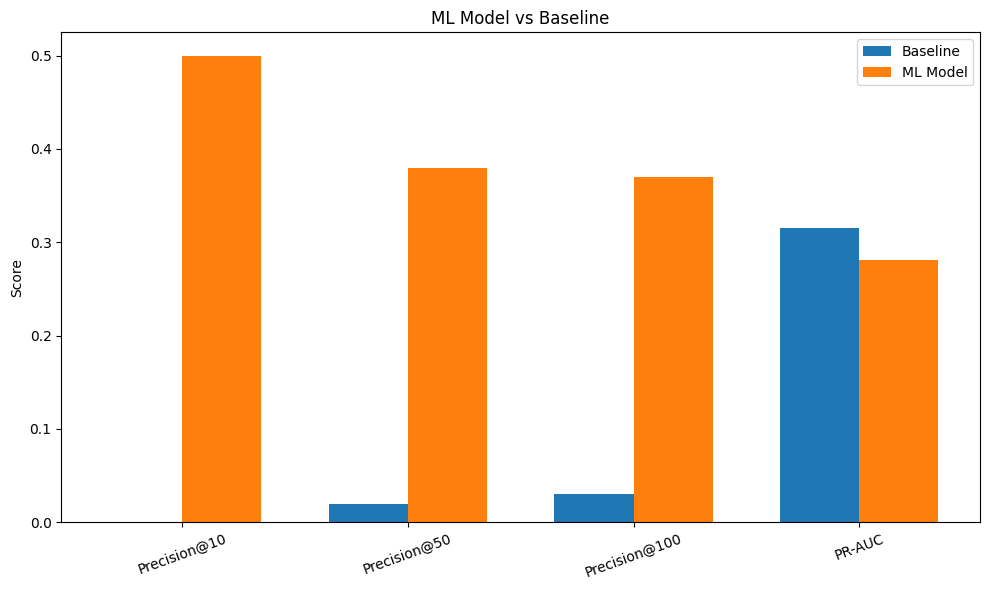

In [10]:
# ==========================================
# SECTION 4B: Results Visualization
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

print("Creating model vs baseline chart...")

metrics = results["Metric"]
baseline_values = results["Baseline"]
ml_values = results["ML Model"]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, ml_values, width, label="ML Model")

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("ML Model vs Baseline")
plt.legend()
plt.tight_layout()

plt.show()

In [11]:
# ==========================================
# SECTION 5: Limitations & Honest Framing
# ==========================================

print("SECTION 5: Limitations & Honest Framing")
print("=" * 50)

limitations = [
    "The model identifies statistical associations in the available search data; it does not establish causal relationships.",
    "Higher model scores should be interpreted as prioritization signals, not guaranteed future performance.",
    "The ML model performed better than the baseline on Precision@10, Precision@50, and Precision@100, but its PR-AUC was lower than the baseline.",
    "The target represents whether future clicks were greater than zero, so the model does not predict the exact number of future clicks.",
    "The analysis uses a historical dataset and therefore may not fully represent future search behavior or changing market conditions.",
    "Recommendations are intended for decision support and should be reviewed alongside editorial, business, and search-context information.",
    "Client and content identifiers are anonymized to preserve privacy and comply with the public-data rules."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

print("\nHonest interpretation:")
print(
    "The model is best viewed as a prioritization tool for identifying "
    "content that deserves review. It should not be interpreted as proof "
    "that refreshing a page will cause improved search performance."
)

SECTION 5: Limitations & Honest Framing
1. The model identifies statistical associations in the available search data; it does not establish causal relationships.
2. Higher model scores should be interpreted as prioritization signals, not guaranteed future performance.
3. The ML model performed better than the baseline on Precision@10, Precision@50, and Precision@100, but its PR-AUC was lower than the baseline.
4. The target represents whether future clicks were greater than zero, so the model does not predict the exact number of future clicks.
5. The analysis uses a historical dataset and therefore may not fully represent future search behavior or changing market conditions.
6. Recommendations are intended for decision support and should be reviewed alongside editorial, business, and search-context information.
7. Client and content identifiers are anonymized to preserve privacy and comply with the public-data rules.

Honest interpretation:
The model is best viewed as a prioritization

In [12]:
# ==========================================
# SECTION 6: Ranked Recommendations
# ==========================================

print("SECTION 6: Ranked Recommendations")
print("=" * 50)

top_recommendations = recommendations[
    [
        "final_rank",
        "content_id",
        "final_refresh_score",
        "confidence",
        "suggested_action",
        "final_reason_codes",
        "trend_direction",
        "ctr",
        "avg_position",
        "word_count"
    ]
].head(20).copy()

print("\nTop 20 Ranked Content Recommendations")
print("-" * 50)

display(top_recommendations)

print("\nAction Playbook")
print("-" * 30)

action_counts = recommendations["suggested_action"].value_counts()

for action, count in action_counts.items():
    print(f"{action}: {count} recommendations")

print("\nRecommendation strategy:")
print(
    "Prioritize high-confidence pages with strong refresh scores, "
    "declining trends, visibility, and low engagement signals. "
    "Pages with refresh_and_review_ctr should receive CTR-focused review, "
    "while refresh recommendations should receive broader content updates."
)

SECTION 6: Ranked Recommendations

Top 20 Ranked Content Recommendations
--------------------------------------------------


,final_rank,content_id,final_refresh_score,confidence,suggested_action,final_reason_codes,trend_direction,ctr,avg_position,word_count
0,1,content_1f080331fa2b,81.636697,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,down,0.05,6.8,1404.0
1,2,content_6aa43079fb0c,81.447656,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.07,3.8,1457.0
2,3,content_d6570c51c9bd,81.430346,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.00,10.1,1362.0
3,4,content_72e800a9c214,81.034960,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.12,8.2,1371.0
4,5,content_e04eb9549989,80.873188,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.09,3.6,1408.0
5,6,content_b69288c5e701,80.754770,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.07,6.4,1370.0
6,7,content_9b6df29f7889,80.632923,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.12,3.1,1415.0
7,8,content_bb6ebb5ec8c8,80.371236,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.00,12.8,1381.0
8,9,content_4d76cdb3387b,80.362748,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,down,0.13,2.7,1554.0
9,10,content_b4f35d640b1c,80.321757,medium,refresh,declining_with_demand|model_decline_risk|visib...,down,0.05,27.5,1389.0



Action Playbook
------------------------------
refresh_and_review_ctr: 130 recommendations
refresh: 35 recommendations
refresh_and_review_engagement: 35 recommendations

Recommendation strategy:
Prioritize high-confidence pages with strong refresh scores, declining trends, visibility, and low engagement signals. Pages with refresh_and_review_ctr should receive CTR-focused review, while refresh recommendations should receive broader content updates.


In [13]:
# ==========================================
# SECTION 7: Reproducibility
# ==========================================

print("SECTION 7: Reproducibility")
print("=" * 50)

print("""
This analysis is reproducible from the project repository.

Repository:
https://github.com/abbottabad123/flyrank-ml-track

The project contains:
- Assignment notebooks
- Capstone notebook
- Model outputs
- Recommendation outputs
- Supporting charts and reports

The final recommendations were generated from the FlyRank ML Internship dataset
using historical search-performance features and a future-click target.

All client and content identifiers used in the public analysis are anonymized.
""")

print("\nReproducibility checklist:")
print("✓ Repository available")
print("✓ Capstone notebook included")
print("✓ Model methodology documented")
print("✓ Validation design documented")
print("✓ Recommendation logic documented")
print("✓ Limitations documented")

SECTION 7: Reproducibility

This analysis is reproducible from the project repository.

Repository:
https://github.com/abbottabad123/flyrank-ml-track

The project contains:
- Assignment notebooks
- Capstone notebook
- Model outputs
- Recommendation outputs
- Supporting charts and reports

The final recommendations were generated from the FlyRank ML Internship dataset
using historical search-performance features and a future-click target.

All client and content identifiers used in the public analysis are anonymized.


Reproducibility checklist:
✓ Repository available
✓ Capstone notebook included
✓ Model methodology documented
✓ Validation design documented
✓ Recommendation logic documented
✓ Limitations documented


In [14]:
print("CAPSTONE AUDIT COMPLETE")
print("========================")
print("Sections completed: 1–7")
print("Recommendations:", len(recommendations))
print("Top recommendation:", recommendations.iloc[0]["content_id"])
print("Top refresh score:", recommendations.iloc[0]["final_refresh_score"])

CAPSTONE AUDIT COMPLETE
Sections completed: 1–7
Recommendations: 200
Top recommendation: content_1f080331fa2b
Top refresh score: 81.63669708126251


In [15]:
# ==========================================
# SECTION 8: Acknowledgments & Data Credit
# ==========================================

print("SECTION 8: Acknowledgments & Data Credit")
print("=" * 50)

print("""
Acknowledgments & Data Credit

This research was built using the FlyRank ML Internship dataset.

Data source:
FlyRank — https://flyrank.ai

The dataset was used for educational and research purposes.
All client and content identifiers presented in the public analysis
are anonymized.

This work does not claim to reveal Google's ranking algorithm or
establish causal effects from content changes.
""")

print("Data credit: Built on the FlyRank ML Internship dataset")
print("Source: https://flyrank.ai")

SECTION 8: Acknowledgments & Data Credit

Acknowledgments & Data Credit

This research was built using the FlyRank ML Internship dataset.

Data source:
FlyRank — https://flyrank.ai

The dataset was used for educational and research purposes.
All client and content identifiers presented in the public analysis
are anonymized.

This work does not claim to reveal Google's ranking algorithm or
establish causal effects from content changes.

Data credit: Built on the FlyRank ML Internship dataset
Source: https://flyrank.ai
